# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon:

- `exact`: symbolic determinant route
- `eigenvalue`: spectral precompute route
- `grid`: spline interpolation over a precomputed grid

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytensor
import pytensor.tensor as pt

from bayespecon.logdet import make_logdet_fn

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def make_line_w(n: int) -> np.ndarray:
    """Create a row-standardized line-lattice W matrix."""
    W = np.zeros((n, n), dtype=np.float64)
    idx = np.arange(n)
    W[idx[1:], idx[:-1]] = 1.0
    W[idx[:-1], idx[1:]] = 1.0
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    return W / row_sums


def compile_logdet_callable(W: np.ndarray, method: str):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    t0 = time.perf_counter()
    rho = pt.scalar('rho')
    expr = make_logdet_fn(W, method=method, rho_min=-0.95, rho_max=0.95)(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [9]:
@dataclass
class ProfileConfig:
    # Include larger sizes to expose high-n behavior.
    sizes: tuple[int, ...] = (40, 80, 120, 180, 260, 360, 520, 720, 1000, 2000, 5000, 10000)
    methods: tuple[str, ...] = ('exact', 'eigenvalue', 'grid')
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3

    def __post_init__(self):
        if self.method_max_n is None:
            # Practical safety caps for this dense benchmark setup.
            # - exact grows quickly, keep only small n
            # - grid allocates an n_grid x n x n tensor internally
            # - eigenvalue requires dense eigendecomposition
            self.method_max_n = {
                'exact': 120,
                'eigenvalue': 2000,
                'grid': 1000,
            }


cfg = ProfileConfig()
rho_grid = np.linspace(-0.9, 0.9, cfg.eval_points)
results = []
skipped = []

for n in cfg.sizes:
    W = make_line_w(n)
    print(f'Profiling n={n}...')
    for method in cfg.methods:
        if n > cfg.method_max_n[method]:
            skipped.append({'n': n, 'method': method, 'reason': 'above method_max_n cap'})
            continue
        try:
            fn, setup_s = compile_logdet_callable(W, method)
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append({
                'n': n,
                'method': method,
                'setup_ms': 1e3 * setup_s,
                'eval_us': 1e6 * eval_s,
            })
        except Exception as exc:
            skipped.append({'n': n, 'method': method, 'reason': f'failed: {type(exc).__name__}'})

res = pd.DataFrame(results).sort_values(['method', 'n']).reset_index(drop=True)
if not res.empty:
    # Total cost for a full rho sweep used in this notebook.
    res['total_ms'] = res['setup_ms'] + (res['eval_us'] * cfg.eval_points / 1e3)
res

Profiling n=40...
Profiling n=80...
Profiling n=120...
Profiling n=180...
Profiling n=260...
Profiling n=360...
Profiling n=520...
Profiling n=720...
Profiling n=1000...
Profiling n=2000...
Profiling n=5000...
Profiling n=10000...


,n,method,setup_ms,eval_us,total_ms
0,40,eigenvalue,7.757458,2.955727,7.993916
1,80,eigenvalue,8.477459,2.860429,8.706293
2,120,eigenvalue,8.564875,2.831244,8.791374
3,180,eigenvalue,13.741750,3.304682,14.006125
4,260,eigenvalue,21.798125,3.701029,22.094207
5,360,eigenvalue,35.122083,4.265097,35.463290
6,520,eigenvalue,72.941417,4.100509,73.269458
7,720,eigenvalue,122.501542,5.013531,122.902624
8,1000,eigenvalue,198.825333,5.589577,199.272499
9,2000,eigenvalue,873.163833,8.811464,873.868750


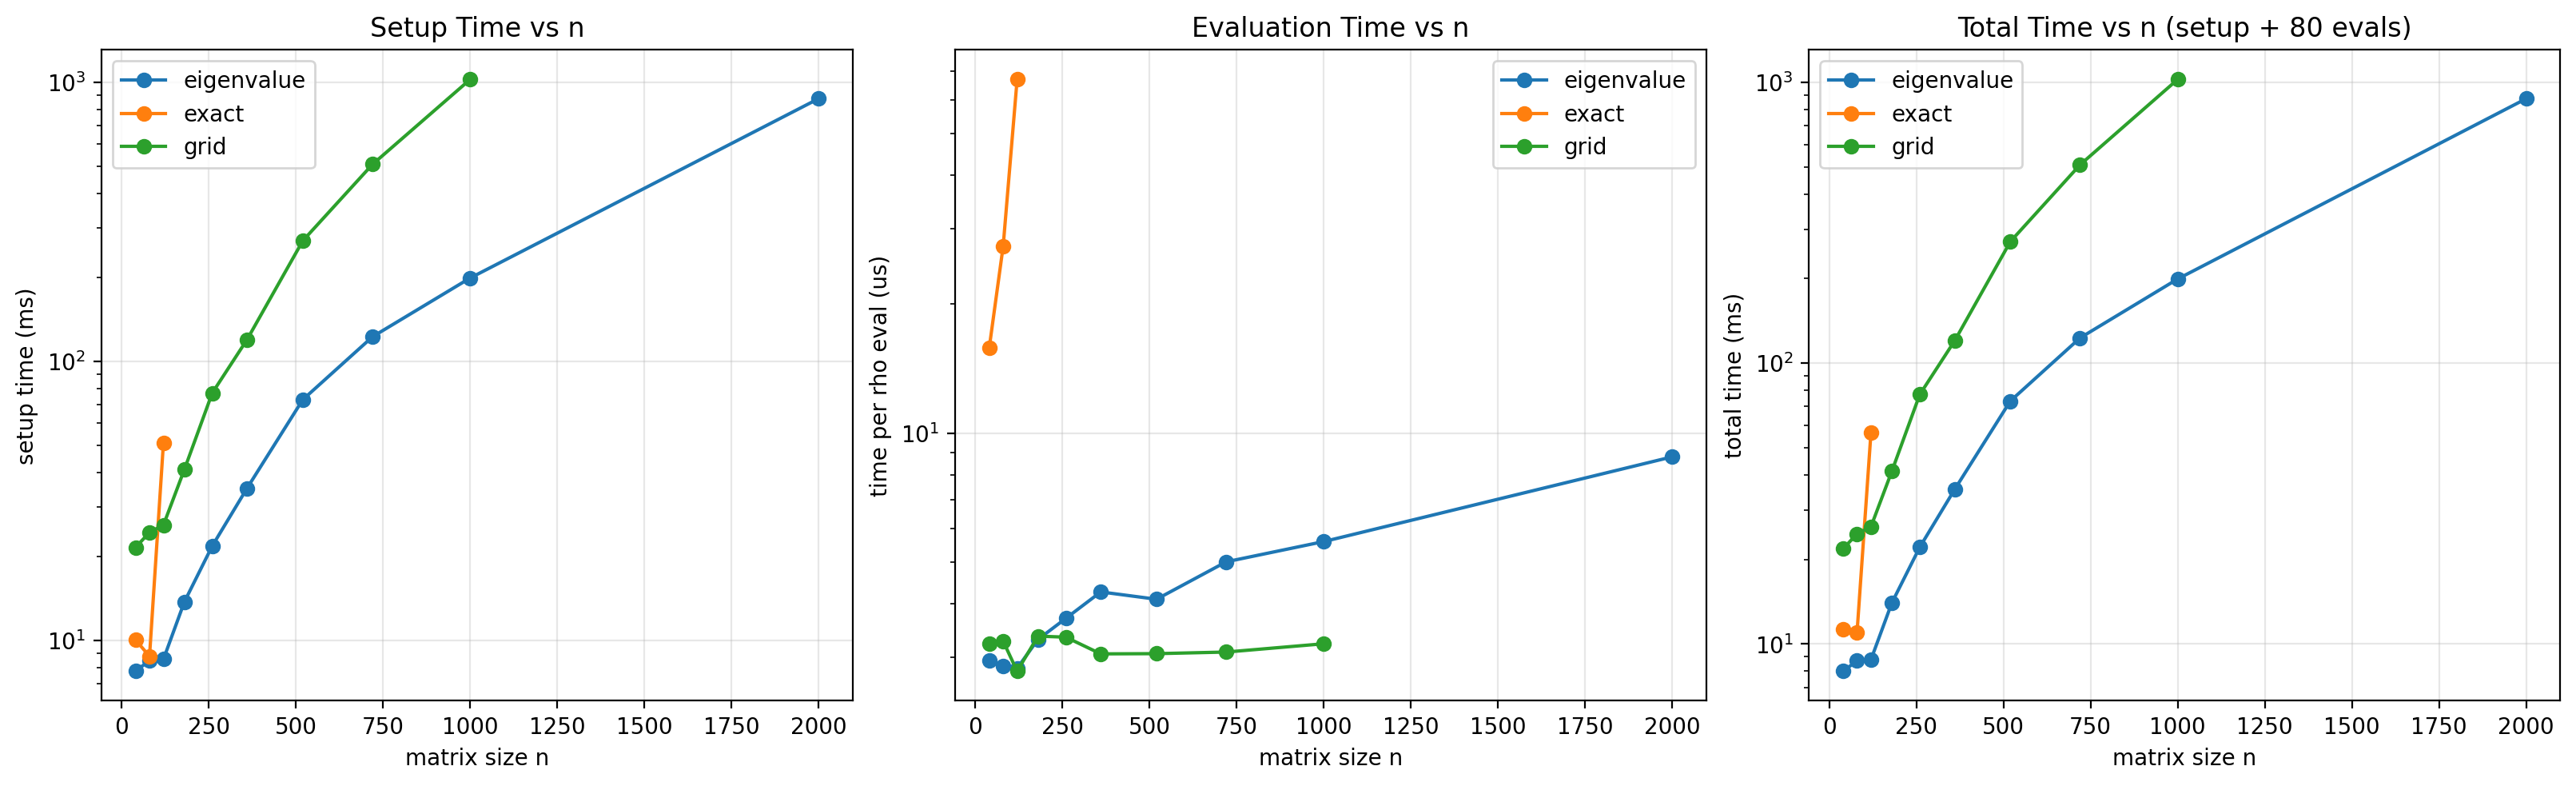

In [10]:
if res.empty:
    raise RuntimeError('No profiling results were generated.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for method, grp in res.groupby('method'):
    grp = grp.sort_values('n')
    axes[0].plot(grp['n'], grp['setup_ms'], marker='o', label=method)
    axes[1].plot(grp['n'], grp['eval_us'], marker='o', label=method)
    axes[2].plot(grp['n'], grp['total_ms'], marker='o', label=method)

axes[0].set_title('Setup Time vs n')
axes[0].set_xlabel('matrix size n')
axes[0].set_ylabel('setup time (ms)')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Evaluation Time vs n')
axes[1].set_xlabel('matrix size n')
axes[1].set_ylabel('time per rho eval (us)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f'Total Time vs n (setup + {cfg.eval_points} evals)')
axes[2].set_xlabel('matrix size n')
axes[2].set_ylabel('total time (ms)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()

In [11]:
summary = (
    res.pivot_table(index='n', columns='method', values=['setup_ms', 'eval_us', 'total_ms'])
       .sort_index()
)
display(summary)

if skipped:
    skipped_df = pd.DataFrame(skipped).sort_values(['n', 'method']).reset_index(drop=True)
    print('Skipped combinations (due to safety caps or failures):')
    display(skipped_df)

eval_us                         setup_ms                          \
method eigenvalue      exact      grid  eigenvalue      exact         grid   
n                                                                            
40       2.955727  15.820318  3.228651    7.757458  10.042875    21.536999   
80       2.860429  27.322385  3.273436    8.477459   8.769793    24.402541   
120      2.831244  66.878134  2.785947    8.564875  51.140000    25.916667   
180      3.304682        NaN  3.363553   13.741750        NaN    40.947250   
260      3.701029        NaN  3.344787   21.798125        NaN    76.995709   
360      4.265097        NaN  3.057811   35.122083        NaN   119.707833   
520      4.100509        NaN  3.061467   72.941417        NaN   270.528167   
720      5.013531        NaN  3.088021  122.501542        NaN   508.028834   
1000     5.589577        NaN  3.228639  198.825333        NaN  1023.219917   
2000     8.811464        NaN       NaN  873.163833        NaN          NaN   

          total_ms                          
method  eigenvalue      exact         grid  
n                                           
40        7.993916  11.308501    21.795291  
80        8.706293  10.955583    24.664416  
120       8.791374  56.490251    26.139542  
180      14.006125        NaN    41.216334  
260      22.094207        NaN    77.263292  
360      35.463290        NaN   119.952458  
520      73.269458        NaN   270.773084  
720     122.902624        NaN   508.275876  
1000    199.272499        NaN  1023.478208  
2000    873.868750        NaN          NaN

Skipped combinations (due to safety caps or failures):


,n,method,reason
0,180,exact,above method_max_n cap
1,260,exact,above method_max_n cap
2,360,exact,above method_max_n cap
3,520,exact,above method_max_n cap
4,720,exact,above method_max_n cap
5,1000,exact,above method_max_n cap
6,2000,exact,above method_max_n cap
7,2000,grid,above method_max_n cap
8,5000,eigenvalue,above method_max_n cap
9,5000,exact,above method_max_n cap


## Notes

- `exact` is expected to scale poorly and is intentionally capped at smaller n in this notebook.
- `eigenvalue` usually has moderate setup cost and very fast repeated evaluations.
- `grid` has an upfront grid-construction cost but can be competitive for repeated evaluation scenarios.
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.